## GPU-accelerated computations

In this notebook you will see how to:

- load data using earthkit-data
- change array format of the data
- earthkit-hydro

### Components of earthkit

This tutorial uses the following earthkit components - click any logo to open the package documentation:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-hydro.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg" alt="earthkit-hydro" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a> 
</div>

> Note: some of the examples in this notebook requires an optional dependency - the Python package **cupy**. Prior to running the notebook, install it following the relevant instructions [here](https://docs.cupy.dev/en/stable/install.html).

In [1]:
import earthkit.data as ekd
import earthkit.hydro as ekh
import earthkit.plots as ekp

### 1. Load a large dataset

In [2]:
ds = ekd.from_source("sample", "R06a.nc").to_xarray()
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 40, lat: 2970, lon: 4530)
Coordinates:
  * lat      (lat) float64 24kB 72.24 72.22 72.21 72.19 ... 22.79 22.77 22.76
  * lon      (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * time     (time) datetime64[ns] 320B 2024-11-14T06:00:00 ... 2024-11-24
Data variables:
    R06a     (time, lat, lon) float32 2GB ...
Attributes:
    history:  Wed Mar  8 12:00:44 2023: ncks -O --mk_rec_dmn time area.templa...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [3]:
da = ds["R06a"].isel(time=slice(0,5))
da

<xarray.DataArray 'R06a' (time: 5, lat: 2970, lon: 4530)> Size: 269MB
[67270500 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 24kB 72.24 72.22 72.21 72.19 ... 22.79 22.77 22.76
  * lon      (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * time     (time) datetime64[ns] 40B 2024-11-14T06:00:00 ... 2024-11-15T06:...
Attributes:
    units:          mm
    standard_name:  precipitation
    long_name:      precipitation

### 2. Load a river network

In [4]:
net = ekh.river_network.load("efas", "5")

River network not found in cache (/dev/shm/_tmpdir_.ecm7348.39927645/tmpc7_stich_earthkit_hydro/1.3_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).
River network loaded, saving to cache (/dev/shm/_tmpdir_.ecm7348.39927645/tmpc7_stich_earthkit_hydro/1.3_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).


### 3. Conduct array-level computation using numpy

In [5]:
array_np = da.values

%timeit ekh.upstream.array.sum(net, array_np)

2.02 s ± 67.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 4. Conduct same operation with cupy

In [6]:
import cupy as cp
net_gpu = ekh.river_network.load("efas", "5").to_device(device="cuda")
array_cp = cp.array(da.values)

%timeit ekh.upstream.array.sum(net_gpu, array_cp)

Loading river network from cache (/dev/shm/_tmpdir_.ecm7348.39927645/tmpc7_stich_earthkit_hydro/1.3_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).
172 ms ± 1.46 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 5. Xarray computation backed by numpy

In [7]:
small_da = da.isel(time=0)
%timeit ekh.upstream.sum(net, small_da)

190 ms ± 4.18 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 6. Xarray computation backed by cupy

In [9]:
small_da_gpu = small_da.copy(data=cp.asarray(small_da.data))
%timeit ekh.upstream.sum(net_gpu, small_da_gpu)

163 ms ± 22.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 7. Plotting

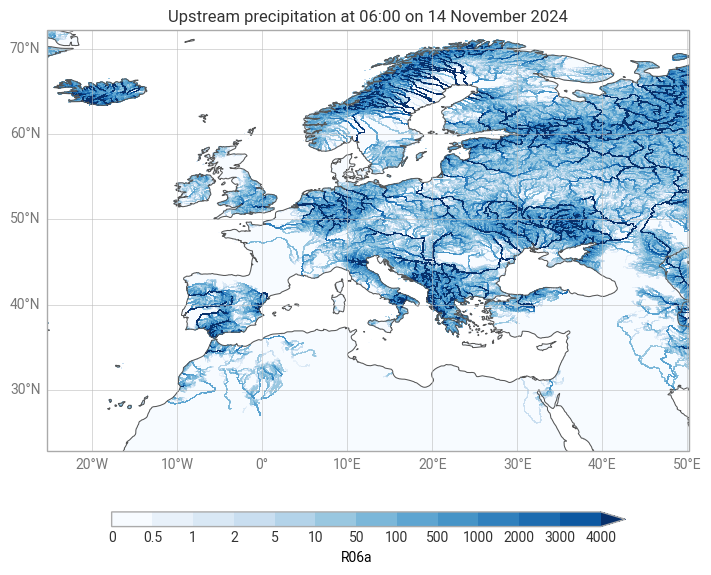

In [10]:
style = ekp.styles.Style(
    colors="Blues",
    levels=[0, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, 2000, 3000, 4000],
    extend="max",
)

upstream_sum = ekh.upstream.sum(net, small_da)

chart = ekp.Map()
chart.quickplot(upstream_sum, style=style)
chart.legend(label="{variable_name}")
chart.title("Upstream precipitation at {time:%H:%M on %-d %B %Y}")
chart.coastlines()
chart.gridlines()
chart.show()